In [22]:
!pip install nltk torch numpy matplotlib seaborn wordcloud pandas tqdm

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from tqdm import tqdm # For progress bar
import nltk

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Dataset Preparation

In [24]:
document = """The Last Train Journey

On a cold winter evening, Daniel arrived at the old railway station carrying a small leather bag.
The station was nearly empty except for a few passengers waiting quietly on wooden benches.
A loud whistle echoed through the air as the final train of the night slowly entered the platform.

Daniel checked the ticket in his pocket and walked toward the train.
The metal doors opened with a creaking sound and warm air rushed outside.
Inside the train, yellow lights flickered softly above rows of empty seats.

He chose a seat beside the window and placed his bag carefully near his feet.
As the train began to move, the city lights slowly disappeared behind thick clouds of fog.
Snow started falling gently outside while distant mountains appeared under the moonlight.

Across the aisle sat an elderly woman reading an old book with a blue cover.
Every few minutes she looked outside the window as if searching for something familiar.
Daniel noticed a silver necklace around her neck shaped like a small compass.

After several hours, the train stopped at a remote station surrounded by tall pine trees.
Very few people entered or left the train at that place.
A strange silence covered the station as the doors closed once again.

Curious about the woman, Daniel finally started a conversation.
The woman introduced herself as Eleanor and explained that she was returning to her hometown after many years.
She said the town was hidden deep within the northern mountains and was known for its beautiful frozen lake.

As the journey continued, Eleanor shared stories from her childhood.
She described colorful festivals, music performances, and lanterns floating across the lake during winter nights.
Daniel listened carefully while the train moved through snowy valleys and dark forests.

Near midnight, the train suddenly slowed down because heavy snow had covered the tracks ahead.
Passengers became nervous and began discussing possible delays.
Conductors moved through the cabins trying to calm everyone.

Daniel looked outside and saw workers removing snow under bright floodlights.
The freezing wind shook the train slightly while snow continued falling from the dark sky.
Despite the delay, Eleanor remained calm and continued telling her stories.

Several hours later, the tracks were finally cleared and the train resumed its journey.
The passengers sighed with relief as warm coffee was served throughout the cabins.
Daniel and Eleanor continued talking about travel, history, and forgotten places around the world.

Just before sunrise, the train reached the mountain town.
The station was small but beautifully decorated with glowing lamps and snow-covered rooftops.
People wearing thick winter coats walked slowly across the icy streets.

Before leaving, Eleanor handed Daniel a folded piece of paper.
Inside it was a drawing of the frozen lake along with a short message thanking him for the conversation.
Daniel smiled and carefully placed the paper inside his notebook.

As the train departed once again, Daniel stood on the platform watching the sunrise over the mountains.
The cold air, quiet streets, and distant church bells created a peaceful atmosphere he would never forget.
Years later, Daniel would still remember that mysterious winter journey and the stories shared by Eleanor on the last train of the night.
"""

# Tokenize the text
tokens = word_tokenize(document.lower())
print(f"Total tokens in the document: {len(tokens)}")

Total tokens in the document: 595


# Exploratory Data Analysis (EDA)

C:\Users\skmah\AppData\Local\Temp\ipykernel_15068\602005438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_words, palette='magma')


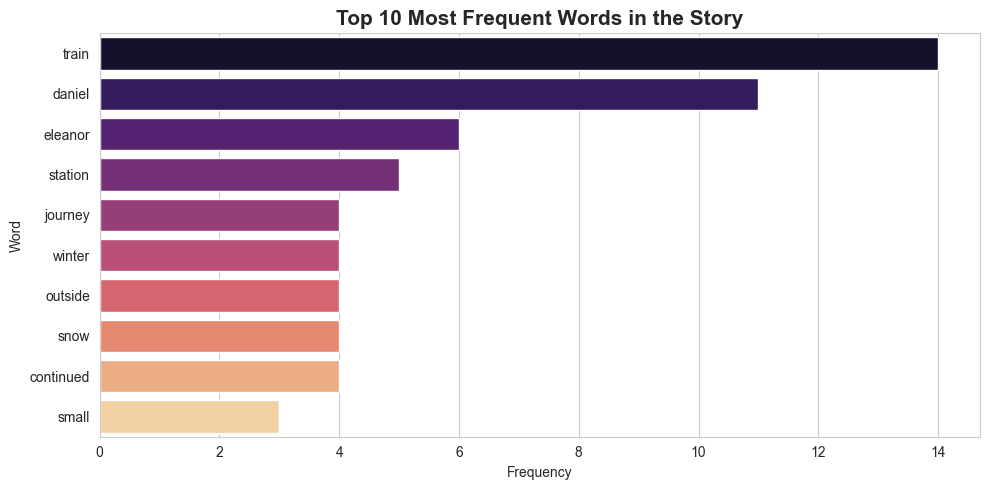

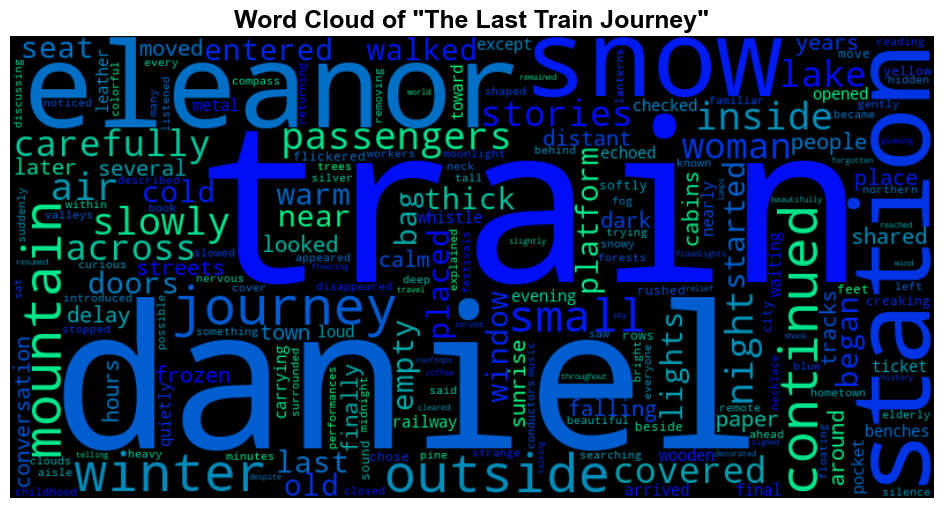

In [25]:
# Filter stop words and punctuations for better visualization
stop_words = set(['the', 'a', 'and', 'of', 'to', 'in', 'was', 'with', 'on', 'as', 'he', 'his', 'her', 'she', 'for', 'it', 'at', 'that', '.', ','])
filtered_tokens = [w for w in tokens if w not in stop_words]

# 1. Plot Top 10 Frequent Words
word_freq = Counter(filtered_tokens)
common_words = word_freq.most_common(10)
df_words = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Word', data=df_words, palette='magma')
plt.title('Top 10 Most Frequent Words in the Story', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Plot Word Cloud
text_for_cloud = " ".join(filtered_tokens)
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='winter').generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of "The Last Train Journey"', fontsize=18, fontweight='bold', color='black')
plt.show()

# Build Vocabulary & Sequences

In [26]:
# Build Vocabulary
vocab = {'<unk>': 0}
for token in Counter(tokens).keys():
    if token not in vocab:
        vocab[token] = len(vocab)

print(f"Vocabulary Size: {len(vocab)}")

# Function to convert text to numerical indices
def text_to_indices(sentence, vocab):
    return [vocab.get(token, vocab['<unk>']) for token in sentence]

# Extract sentences and convert to numerical format
input_sentences = document.split('\n')
input_numerical_sentence = [text_to_indices(word_tokenize(sentence.lower()), vocab) for sentence in input_sentences if sentence.strip() != '']

# Generate Training Sequences (N-grams)
training_sequence = []
for sentence in input_numerical_sentence:
    for i in range(1, len(sentence)):
        training_sequence.append(sentence[:i+1])

print(f"Total training sequences generated: {len(training_sequence)}")

Vocabulary Size: 284
Total training sequences generated: 555


# Padding and Tensor Conversion

In [27]:
# Find max sequence length
max_len = max([len(seq) for seq in training_sequence])
print(f"Max sequence length for padding: {max_len}")

# Pad sequences (Pre-padding with 0)
padded_training_sequence = []
for seq in training_sequence:
    padded_seq = [0] * (max_len - len(seq)) + seq
    padded_training_sequence.append(padded_seq)

# Convert to PyTorch Tensors
padded_training_sequence = torch.tensor(padded_training_sequence, dtype=torch.long)

# Split into Features (X) and Labels (y)
X = padded_training_sequence[:, :-1]
y = padded_training_sequence[:, -1]

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Max sequence length for padding: 25
Shape of X: torch.Size([555, 24]), Shape of y: torch.Size([555])


# PyTorch Dataset & DataLoader

In [28]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CustomDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define the LSTM Architecture

In [29]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=150):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # batch_first=True makes input shape: (batch_size, seq_len, input_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True) 
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        intermediate_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(embedded)
        output = self.fc(final_hidden_state.squeeze(0))
        return output

# Initialize model and move to Device (GPU/CPU)
model = LSTMModel(len(vocab)).to(device)
print(model)

LSTMModel(
  (embedding): Embedding(284, 100)
  (lstm): LSTM(100, 150, batch_first=True)
  (fc): Linear(in_features=150, out_features=284, bias=True)
)


# Training the Model

In [30]:
epochs = 50
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

print(" Starting Model Training...")
# Wrap epochs in tqdm for a cool progress bar
for epoch in tqdm(range(epochs), desc="Training Epochs"):
    total_loss = 0
    
    for batch_x, batch_y in dataloader:
        # Move data to GPU/CPU
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        output = model(batch_x)
        
        # Calculate loss and backward pass
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

print("\n Training Complete!")

 Starting Model Training...


Training Epochs: 100%|██████████| 50/50 [00:06<00:00,  8.17it/s]


 Training Complete!


# Visualize Model Loss Curve

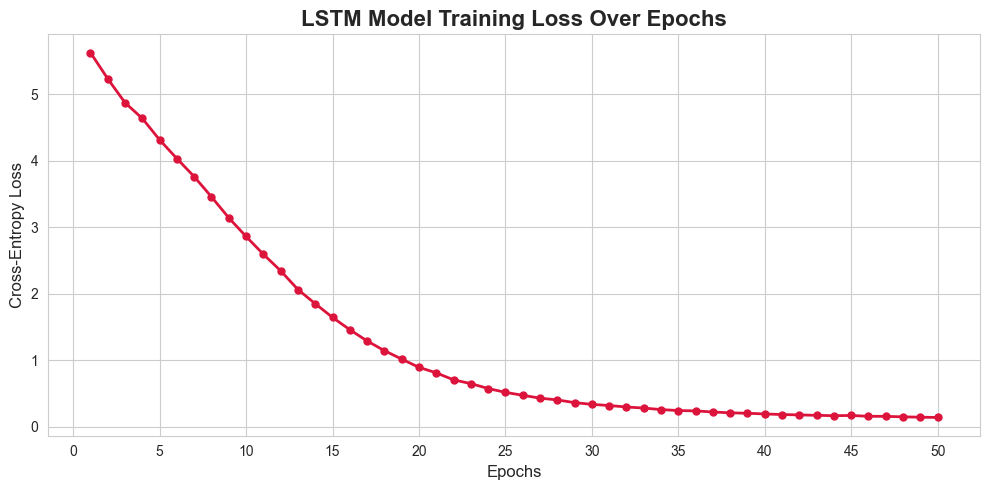

In [31]:
# Plot Training Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='crimson', linestyle='-', linewidth=2, markersize=5)
plt.title('LSTM Model Training Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.xticks(range(0, epochs + 1, 5))
plt.grid(True)
plt.tight_layout()
plt.show()

# Text Generation (Prediction Function)

In [32]:
import torch.nn.functional as F
import time

def predict_next_word(model, vocab, text, max_len=24, temperature=0.7):
    model.eval()
    tokenized_text = word_tokenize(text.lower())
    numerical_text = text_to_indices(tokenized_text, vocab)
    
    numerical_text = numerical_text[-max_len:]
    
    padded_text = torch.tensor([0] * (max_len - len(numerical_text)) + numerical_text, dtype=torch.long).unsqueeze(0)
    padded_text = padded_text.to(device)
    
    with torch.no_grad():
        output = model(padded_text)
        
        logits = output / temperature
        probabilities = F.softmax(logits, dim=1)
        
        predicted_index = torch.multinomial(probabilities, num_samples=1).item()
    
    predicted_word = list(vocab.keys())[predicted_index]
    return predicted_word

In [33]:
print(" Generating Story: \n")
input_text = 'Daniel checked the ticket'
generated_text = input_text
num_tokens_to_generate = 10

for _ in range(num_tokens_to_generate):
    next_word = predict_next_word(model, vocab, generated_text, max_len=max_len-1, temperature=0.7)
    
    if next_word in ['.', ',', '!', '?']:
        generated_text += next_word
    else:
        generated_text += " " + next_word
        
    print(generated_text)
    time.sleep(0.3)
    
    if next_word == '.':
        print("\n Sentence Completed!")
        break

 Generating Story: 

Daniel checked the ticket in
Daniel checked the ticket in his
Daniel checked the ticket in his pocket
Daniel checked the ticket in his pocket and
Daniel checked the ticket in his pocket and walked
Daniel checked the ticket in his pocket and walked toward
Daniel checked the ticket in his pocket and walked toward the
Daniel checked the ticket in his pocket and walked toward the platform
Daniel checked the ticket in his pocket and walked toward the platform.

 Sentence Completed!


# Accuracy Evaluation

In [34]:
def calculate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            _, predicted = torch.max(output, dim=1)
            
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)
            
    accuracy = (correct / total) * 100
    return accuracy

final_acc = calculate_accuracy(model, dataloader, device)
print(f'Final Model Accuracy: {final_acc:.2f}%')

Final Model Accuracy: 96.94%
